# Exploratory Data Analysis

This notebook explores the clean survival table to understand the composition of the analytical cohort, retention patterns and factors associated with churn.

It covers:

- **Analytical Cohort:** Examining left truncation and final cohort definition.
- **Overall Retention:** Examining how retention changes over time across the full cohort.
- **Cohort Retention:** Comparing retention patterns across acquisition cohorts using a retention matrix.
- **Churn by Feature:** Exploring how churn varies across key customer and subscription characteristics.
- **Bivariate Relationships:** Examining relationships between pairs of features and their association with churn.

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.1)

## Left Truncation

The KKBox transactions dataset only starts capturing records from a fixed point in January 2015, which is the observation window. This means users who registered before that date could have already subscribed, churned, resubscribed, or done all of the above before the observation window opens, none of which we can see. So for any user, "the first transaction visible in the data" is not reliably the same thing as "this user's first-ever subscription." For pre-2015 registrants, it might be their first, or it might be their fifth. There's no way to confirm.

**Why it matters:** If we set every user's survival clock to start at their first observed transaction, long-time subscribers who churned and returned get treated exactly the same as true first_time subscribers. That  mixes two different populations and it could bias the survival curves and Cox estimates, since "time since first transaction" doesn't mean the same thing for both groups.

**Our Solution:** We restrict the analysis to users who registered in 2015 or later. Since registration precedes any subscription, these users could not have subscribed before the window opened. That means their first transaction in the transactions dataset is guaranteed to be their true first subscription, as far as we know.

### Visualise Registration Dates

In [ ]:
# Load members data to see registration dates
members = pd.read_csv('data/members_v3.csv')

In [18]:
members.head()

,msno,city,bd,gender,registered_via,registration_init_time,registration_year
0,Rb9UwLQTrxzBVwCB6+bCcSQWZ9JiNLC9dXtM1oEsZA8=,1,0,NaN,11,20110911,2011
1,+tJonkh+O1CA796Fm5X60UMOtB6POHAwPjbTRVl/EuU=,1,0,NaN,7,20110914,2011
2,cV358ssn7a0f7jZOwGNWS07wCKVqxyiImJUX6xcIwKw=,1,0,NaN,11,20110915,2011
3,9bzDeJP6sQodK73K5CBlJ6fgIQzPeLnRl0p5B77XP+g=,1,0,NaN,11,20110915,2011
4,WFLY3s7z4EZsieHCt63XrsdtfTEmJ+2PnnKLH5GY4Tk=,6,32,female,9,20110915,2011


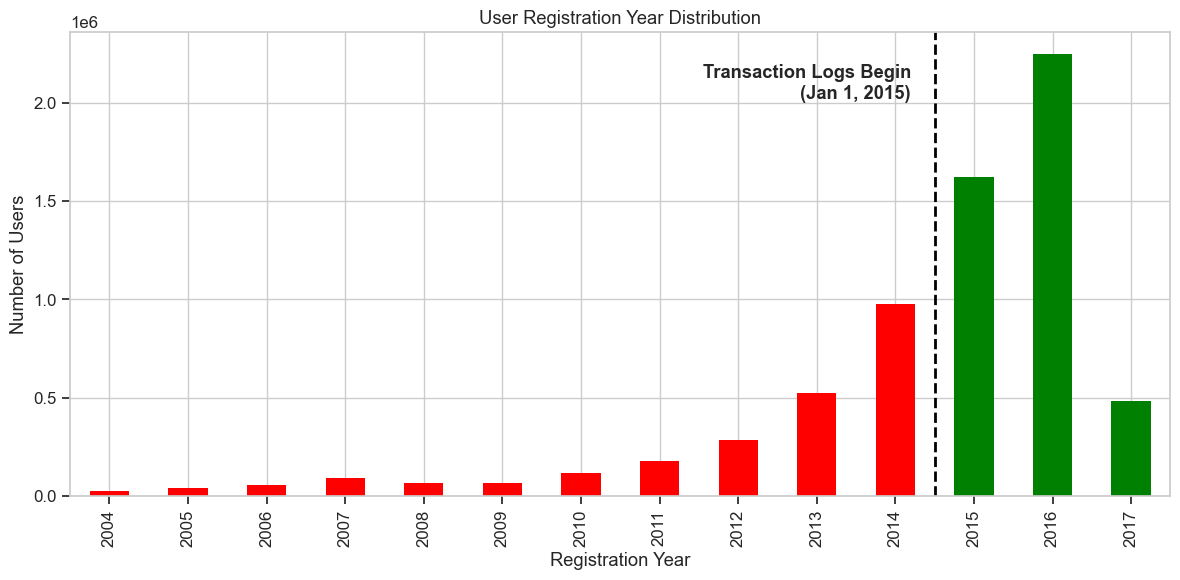

In [ ]:
# Get the registration years
members['registration_year'] = pd.to_datetime(members['registration_init_time'], format='%Y%m%d', errors='coerce').dt.year

plt.figure(figsize=(12, 6))
year_counts = members['registration_year'].value_counts().sort_index()
colors = ['red' if y < 2015 else 'green' for y in year_counts.index]
year_counts.plot(kind='bar', color=colors)

plt.axvline(x=list(year_counts.index).index(2015) - 0.5, color='black', linestyle='--', linewidth=2)
plt.text(list(year_counts.index).index(2015) - 0.8, year_counts.max() * 0.9, 
         'Transaction Logs Begin\n(Jan 1, 2015)', ha='right', fontweight='bold')

plt.title('User Registration Year Distribution')
plt.xlabel('Registration Year')
plt.ylabel('Number of Users')
plt.tight_layout()
plt.show()

### Restrict survival cohort

In [ ]:
# Load the baseline survival table
survival_table = pd.read_csv('data/survival_table.csv')

# Merge it with the members dataset to get the true registration year
merged_df = pd.merge(survival_table, members[['msno', 'registration_year']], on='msno', how='inner')

# Drop everyone who registered before 2015!
adjusted_df = merged_df[merged_df['registration_year'] >= 2015].copy()
adjusted_df.drop(columns=['registration_year'], inplace=True)

print(f"Baseline Cohort size: {len(survival_table):,} users")
print(f"Adjusted Cohort size: {len(adjusted_df):,} users\n")

adjusted_df.to_csv('data/survival_table_adjusted.csv', index=False)
print("Saved!")


Baseline Cohort size: 2,417,562 users
Adjusted Cohort size: 917,697 users

Saved!


### Limitations

We have restricted the survival table to users who only registered in 2015 or after. But what if a user registered in 2010, for example, yet their first transaction was actually after 2015? Our restriction would ultimately cut them out. To see if they even exist, we would check how many users registered before 2015 but have their first transactions in July 2015. We use July because someone who registered before 2015 and was already subscribed when the observation window opened would likely show a transaction near the start of the window, since they'd have been renewing on their normal cycle. If instead their first appearance was 6+ months in, that gap makes it more plausible they  weren't subscribed yet and this really was their first-ever subscription, not a renewal in the data.

In [ ]:
# Ensure dates are parsed correctly
members['registration_year'] = pd.to_datetime(members['registration_init_time'], format='%Y%m%d', errors='coerce').dt.year
survival_table['start_date'] = pd.to_datetime(survival_table['start_date'])

# Merge survival_table with members to bring in registration_year
merged_df = pd.merge(survival_table, members[['msno', 'registration_year']], on='msno', how='inner')

# Filter for pre-2015 registrants
pre_2015_users = merged_df[merged_df['registration_year'] < 2015].copy()

# Find pre-2015 registrants whose first observed transaction is >= July 2015
late_arrivers = pre_2015_users[pre_2015_users['start_date'] >= '2015-07-01']

print(f"Total Pre-2015 Registrants: {len(pre_2015_users):,}")
print(f"Pre-2015 Registrants with late first transactions (>= 2015-07-01): {len(late_arrivers):,}")
print(f"Percentage of pre-2015 registrants that were late: {len(late_arrivers) / len(pre_2015_users) * 100:.2f}%")


Total Pre-2015 Registrants: 1,066,526
Pre-2015 Registrants who showed up LATE (>= 2015-07-01): 308,352
Percentage of pre-2015 registrants that were late: 28.91%


The restriction excludes 308,352 users who possibly registered before 2015 but whose first observed transaction fell after July 1, 2015 (out of 1,066,526 pre-2015 registrants who transacted during the window). Some of these are plausibly genuine new subscribers, long-time free or inactive members who converted late, but they can't be proven to be new the way the 2015+-registered cohort can, so they're left out of the primary analysis. This means the results describe subscribers who both registered and had their first subscription from 2015 onward, and does not generalise to long-time members who converted later.

### Load the adjusted survival table

In [21]:
df = pd.read_csv("data/survival_table_adjusted.csv", parse_dates=["start_date", "endpoint_date"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 917697 entries, 0 to 917696
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   msno                917697 non-null  object        
 1   start_date          917697 non-null  datetime64[ns]
 2   endpoint_date       917697 non-null  datetime64[ns]
 3   duration_days       917697 non-null  int64         
 4   event               917697 non-null  int64         
 5   payment_method_id   917697 non-null  int64         
 6   payment_plan_days   917697 non-null  int64         
 7   plan_list_price     917697 non-null  int64         
 8   actual_amount_paid  917697 non-null  int64         
 9   is_auto_renew       917697 non-null  int64         
 10  is_cancel           917697 non-null  int64         
dtypes: datetime64[ns](2), int64(8), object(1)
memory usage: 77.0+ MB


In [26]:
df.head()

,msno,start_date,endpoint_date,duration_days,event,payment_method_id,payment_plan_days,plan_list_price,actual_amount_paid,is_auto_renew,is_cancel
0,++/gTmVgKUbNFmsTiriZdWV1uZIrLXCUiEWN0fEU6BM=,2015-11-11,2016-02-15,96,1,41,30,149,0,1,0
1,++096narOxHnDPtbtUtB4WDqDy8EJacQypdqDYBHmmY=,2016-11-26,2016-12-03,7,1,35,7,0,0,0,0
2,++0JQqGo/czgqG5qCY31TYkzV7WUMf2QWAS+OeIs//o=,2016-11-29,2016-12-06,7,1,35,7,0,0,0,0
3,++0XxUiOHZeYOgVDnJlFiXIp3Y7l+x4NLlaSEMOBrFI=,2016-11-26,2016-12-03,7,1,35,7,0,0,0,0
4,++2AQgVgYUAqJDw684tbDqDffUeKhqydyQmbr8lz9lQ=,2015-06-02,2015-06-15,13,1,35,7,0,0,0,0


## Event Analysis


The event in our analysis is churn. Those who haven't churned by the end of the observation window are censored.

### Event Distribution

What is the overall churn rate?

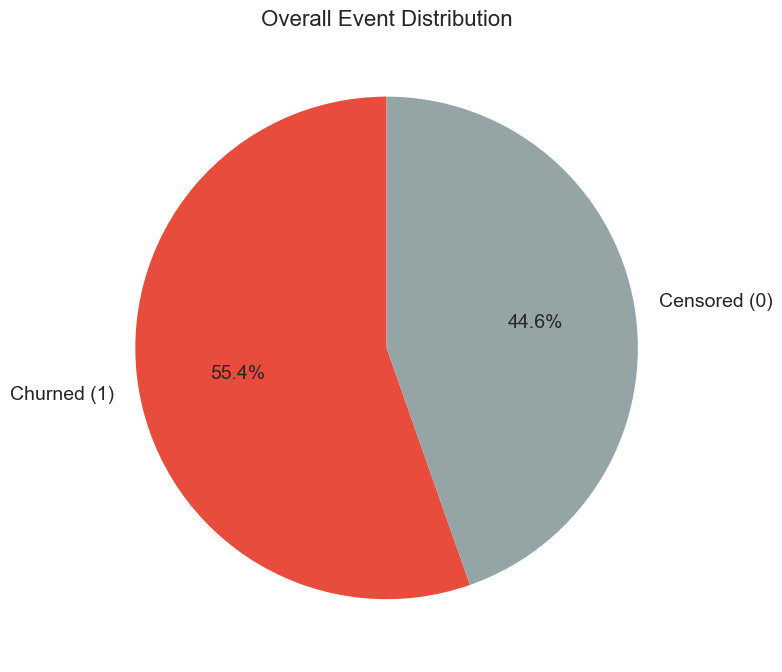

In [32]:
plt.figure(figsize=(8, 8))

# Overall pie
event_counts = df['event'].value_counts()
plt.pie(
    event_counts, 
    labels=['Churned (1)', 'Censored (0)'], 
    autopct='%1.1f%%', 
    colors=['#e74c3c', '#95a5a6'], 
    startangle=90,
    textprops={'fontsize': 14}
)
plt.title('Overall Event Distribution', fontsize=16)

plt.tight_layout()
plt.show()


A little more than half of the users in this cohort churned during the observation window. While that might seem high, having nearly 45% of  users censored means they were still subscribed at the end of the window.

### User Lifespan Distribution

At what specific point in the subscriber lifecycle is the risk of churning the highest?

`duration_days`represents the totallifespan of a user's subscription. For Churned Users, it is the number of days from their first transaction until their first observed churn.
For Censored Users (who never churned), it is the number of days from their first transaction until the observation window closed.

In [ ]:
# Descriptive statistics
df['duration_days'].describe()

count    917697.000000
mean        188.276802
std         207.919024
min           0.000000
25%          13.000000
50%          91.000000
75%         335.000000
max         820.000000
Name: duration_days, dtype: float64

The median reveals half of our users have a lifespan of exactly 91 days which is about 3 months. On the other hand, the mean (188 days) is way higher than the median because  users who stick around for the maximum 820 days are dragging the average up, which is why we always favour the median in survival analysis. Also, the bottom 25% of users don't even make it past two weeks (13 days).

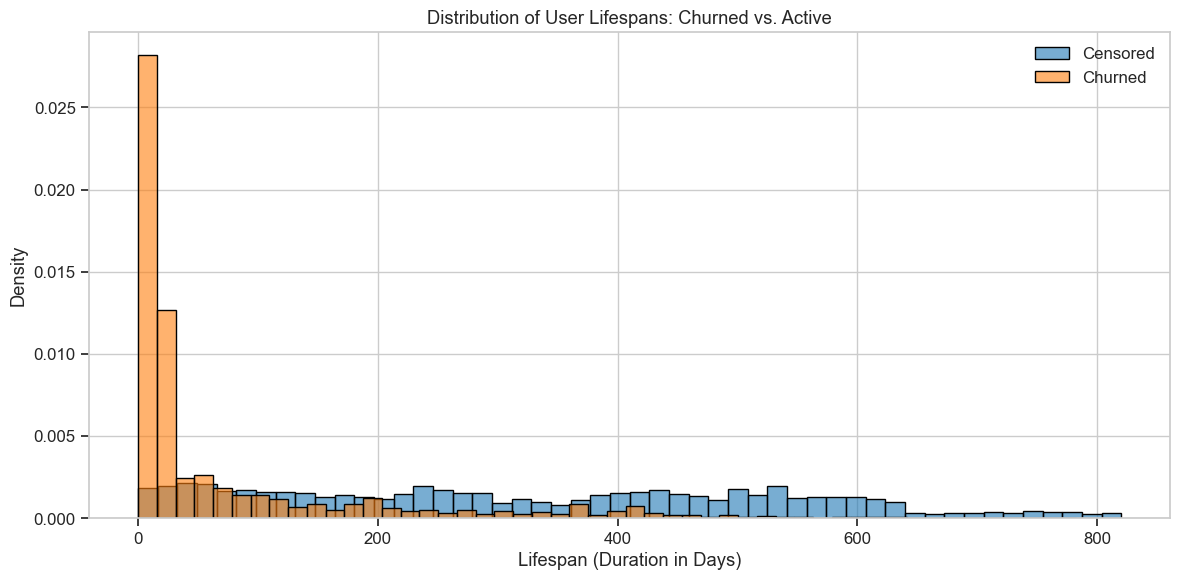

In [33]:
plt.figure(figsize=(12, 6))

# Plot Censored Users (Event = 0)
sns.histplot(
    df[df['event'] == 0]['duration_days'], 
    color='#1f77b4', 
    label='Censored', 
    kde=False, 
    bins=50, 
    alpha=0.6,
    stat='density' # This is so both distributions are on the same scale
)

# Plot Churned Users (Event = 1)
sns.histplot(
    df[df['event'] == 1]['duration_days'], 
    color='#ff7f0e', 
    label='Churned', 
    kde=False, 
    bins=50, 
    alpha=0.6,
    stat='density'
)

plt.title('Distribution of User Lifespans: Churned vs. Active')
plt.xlabel('Lifespan (Duration in Days)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()


The orange spike on the far left shows that majority of users who churn do so almost immediately and usually within their first month or two. On the other hand, the blue bars representing active (censored) users are spread out much more evenly across the entire timeline. This suggests that if we can get a user to survive the initial first few months, they are highly likely to stay subscribed for a long time.

### Cohort Retention Matrix

How does retention quality vary depending on the specific month a user was acquired?

Here, we visualise the **Monthly Retention Matrix.**  A user is "retained in Month M" if their `duration_days` is greater than or equal to `M * 30`. If a cohort hits the edge of our observation window at Month 6, months 7+ will appear empty.

In [23]:
# Create a copy for cohort analysis
cohort_df = df.copy()
cohort_df['acq_month'] = cohort_df['start_date'].dt.to_period('M')


# Max months to track
max_months = 24

# Create a dataframe of all users and their max active month
cohort_df['max_active_month'] = cohort_df['duration_days'] // 30

# Build a matrix where rows are acq_month, cols are month_0 to month_N
retention_matrix = pd.DataFrame(index=sorted(cohort_df['acq_month'].unique()), columns=range(max_months + 1))

for cohort in retention_matrix.index:
    cohort_users = cohort_df[cohort_df['acq_month'] == cohort]
    total_users = len(cohort_users)
    
    for m in range(max_months + 1):
        # A user is active in month 'm' if their max_active_month >= m
        active_users = len(cohort_users[cohort_users['max_active_month'] >= m])
        
        # If a cohort is censored, their max_active_month just stops, leading to 0s
        if active_users == 0 and m > 0:
            retention_matrix.loc[cohort, m] = np.nan # Unobserved
        else:
            retention_matrix.loc[cohort, m] = active_users / total_users

retention_matrix = retention_matrix.astype(float)

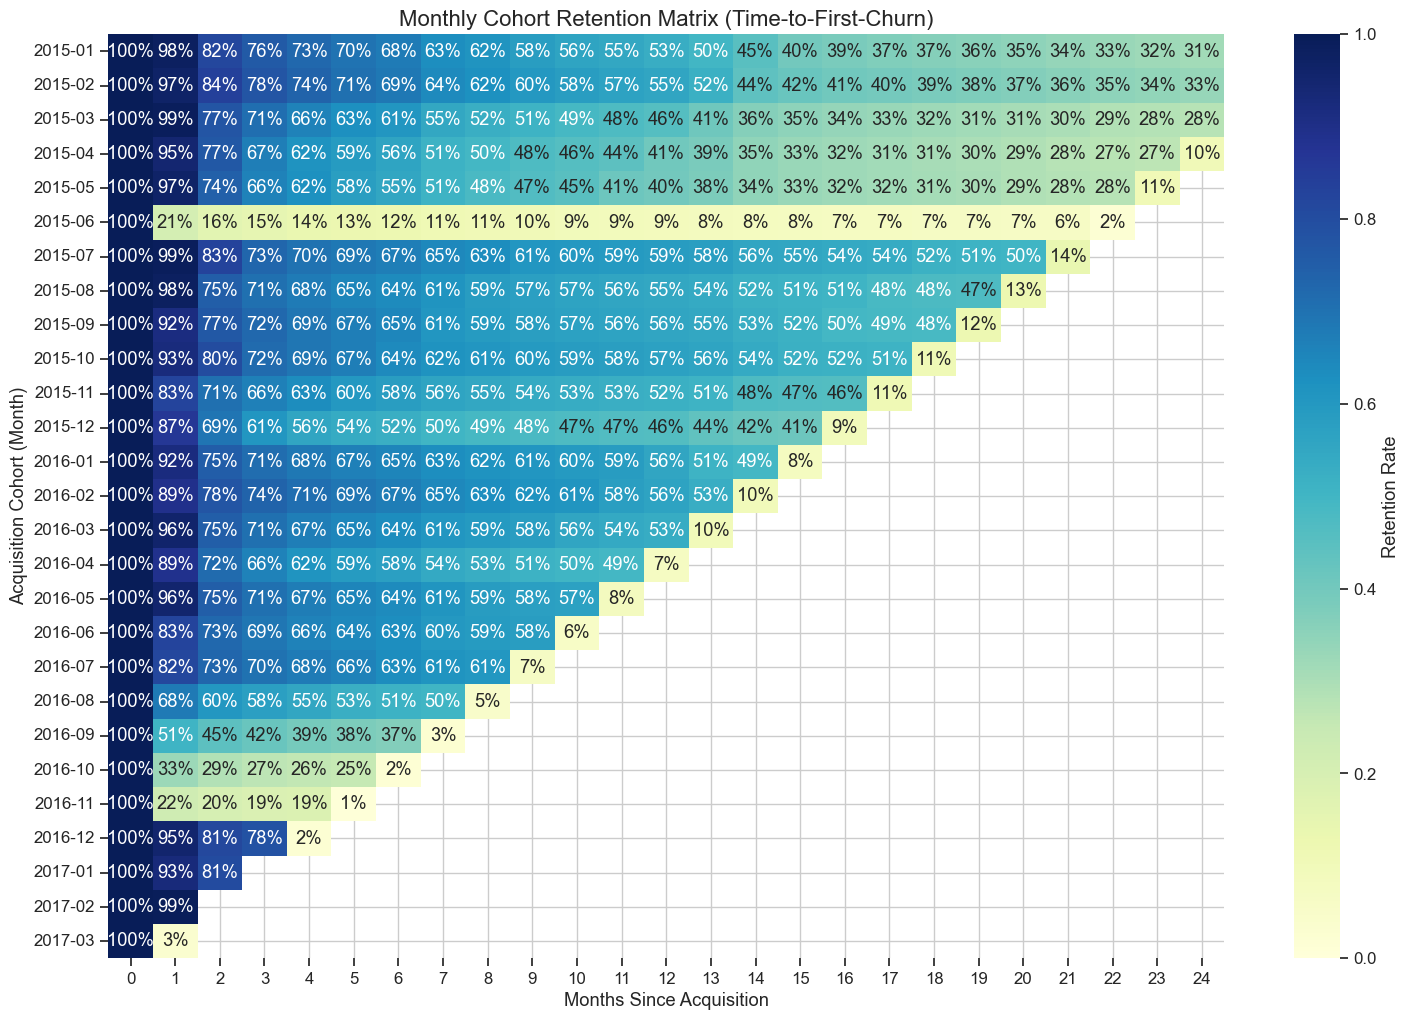

In [24]:
plt.figure(figsize=(18, 12))
sns.heatmap(
    retention_matrix, 
    annot=True, 
    fmt=".0%", 
    cmap="YlGnBu", 
    vmin=0.0, 
    vmax=1.0,
    cbar_kws={'label': 'Retention Rate'}
)
plt.title("Monthly Cohort Retention Matrix (Time-to-First-Churn)", fontsize=16)
plt.ylabel("Acquisition Cohort (Month)")
plt.xlabel("Months Since Acquisition")
plt.show()


1. The June 2015 (2015-06) acquisition cohort experienced a Month 1 retention drop down to 21%, contrasting sharply with the surrounding cohorts (2015-05 and 2015-07), which maintained 97% and 99% Month 1 retention respectively. This significant break points to a specific incident during that month, such as a major platform outage, a localised system failure or a even a flawed user acquisition channel. 
2. Early-stage retention quality deteriorated significantly in the latter part of 2016. Month 1 retention declined  from 68% in August 2016 (2016-08) to a low of 22% by November 2016 (2016-11). It could have been caused by a deteriorating acquisition strategy or an influx of low-quality leads or a product update introduced in Q3 2016. 
3. The earliest cohorts have the most stabilizing retention rates, maintaining a core of users over the long term. The initial January 2015 cohort, for example, retains 31% of its users at the 24-month mark, indicating strong product-market fit and a healthy baseline for early adopters who survive the initial churn periods.  


### Acquisition Volume Over Time
How many users joined the platform each month?

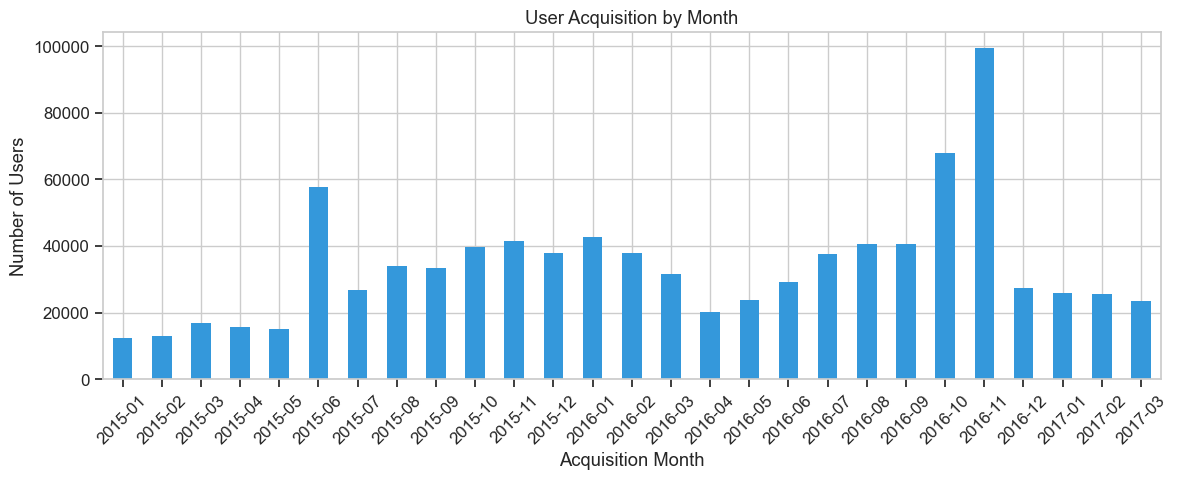

In [34]:
df['acq_month'] = df['start_date'].dt.to_period('M')
acq_counts = df.groupby('acq_month').size()

plt.figure(figsize=(12, 5))
acq_counts.plot(kind='bar', color='#3498db')
plt.title("User Acquisition by Month")
plt.xlabel("Acquisition Month")
plt.ylabel("Number of Users")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The monthly acquisition chart correlates highly with the monthly retention matrix and explains some of the degradations.
1. In June 2015, user acquisition jumped to nearly 60,000 new users from roughly 15,000 the previous month. Correlating this with the retention matrix suggests that this surge consisted of extremely low-intent traffic, as the 2015-06 cohort experienced a Month 1 retention drop to just 21%. This points to an inefficient marketing campaign, a viral influx or bot activity that successfully drove volume but failed to acquire the target audience. 
2. The chart also shows a peak in user acquisition during October and November 2016, resulting in approximately 100,000 new users in November alone. When paired with the retention matrix, it perfectly aligns with the severe drop in early-stage retention, which ended at 22% in Month 1 for the November cohort. This indicates an aggressive growth strategy or promotional event that prioritised volume at the  expense of user quality.

Outside of the spikes in mid-2015 and late 2016, the organic baseline acquisition hovers steadily between 20,000 and 40,000 users per month throughout most of late 2015 and early 2016. The retention matrix confirms that cohorts acquired during these stable periods generally demonstrate much healthier, predictable long-term survival rates.

## Churn by Feature
Next, we examine the absolute volume and relative percentage of churn across our core features.

### Auto-Renewal

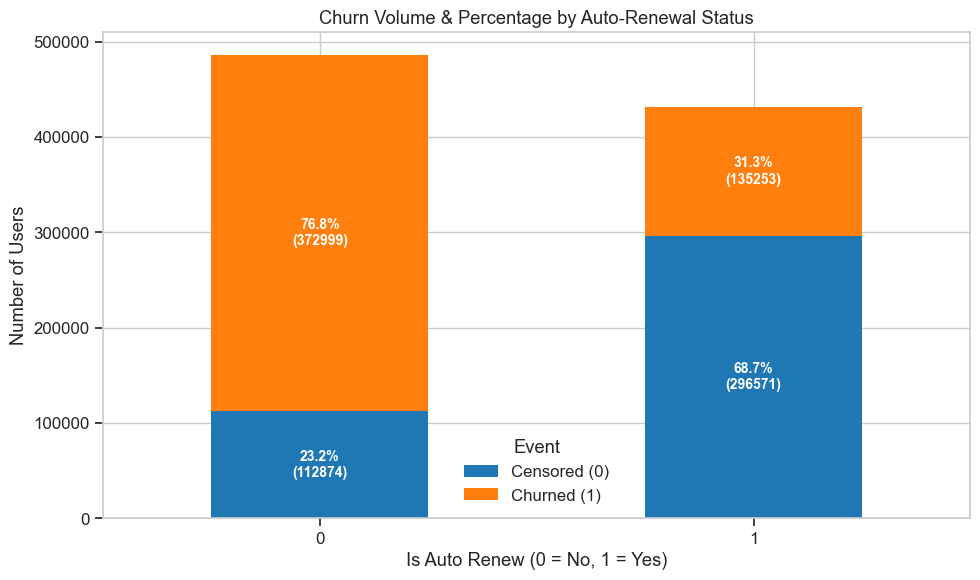

In [37]:
# Auto-Renew Churn Proportions
cross_tab_ar = pd.crosstab(df['is_auto_renew'], df['event'])
cross_tab_ar_pct = cross_tab_ar.div(cross_tab_ar.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 6))
cross_tab_ar.plot(kind='bar', stacked=True, ax=ax, color=['#1f77b4', '#ff7f0e'])

for n, x in enumerate([*cross_tab_ar.index.values]):
    for (proportion, count, y_loc) in zip(cross_tab_ar_pct.loc[x], cross_tab_ar.loc[x], cross_tab_ar.loc[x].cumsum()):
        plt.text(x=n, y=(y_loc - count / 2), 
                 s=f'{proportion:.1f}%\n({count})', 
                 color="white", fontsize=10, fontweight="bold", ha="center", va="center")

plt.title('Churn Volume & Percentage by Auto-Renewal Status')
plt.xlabel('Is Auto Renew (0 = No, 1 = Yes)')
plt.ylabel('Number of Users')
plt.legend(['Censored (0)', 'Churned (1)'], title='Event')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Auto-Renewal Reduces Churn Rate:** The user base is roughly divided in half regarding auto-renewal. Users who do not have auto-renewal enabled experience a churn rate of 76.8%, while enabling auto-renewal cuts the churn rate down by more than half, to just 31.3%. The absolute volume of lost users is heavily concentrated in the manual renewal cohort, with 372,999 users churning compared to 135,253 in the auto-renew group. This indicates that requiring manual payment intervention at the end of a billing cycle is a friction point that drives away the majority of those users.   Additionally, the censored group, representing users who remained active and survived the observation window without churning, is predominantly made up of auto-renewing subscribers. Specifically, 68.7% (296,571 users) of the auto-renew cohort survived, compared to only 23.2% (112,874 users) of the cohort without auto-renew enabled.  

### Payment Methods

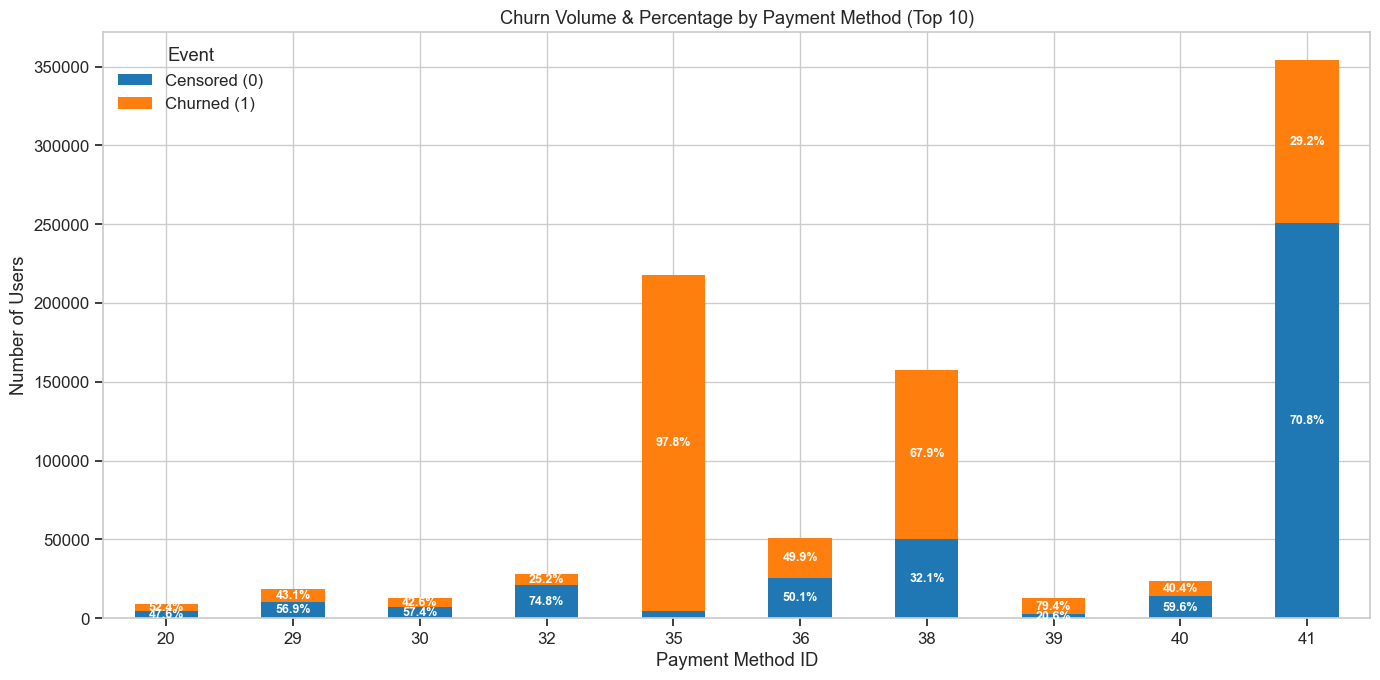

In [38]:
# Payment Method Churn Proportions (Top 10)
top_10_methods = df['payment_method_id'].value_counts().nlargest(10).index
df_top10_pay = df[df['payment_method_id'].isin(top_10_methods)]

cross_tab_pay = pd.crosstab(df_top10_pay['payment_method_id'], df_top10_pay['event'])
cross_tab_pay_pct = cross_tab_pay.div(cross_tab_pay.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 7))
cross_tab_pay.plot(kind='bar', stacked=True, ax=ax, color=['#1f77b4', '#ff7f0e'])

for n, x in enumerate([*cross_tab_pay.index.values]):
    for (proportion, count, y_loc) in zip(cross_tab_pay_pct.loc[x], cross_tab_pay.loc[x], cross_tab_pay.loc[x].cumsum()):
        if proportion > 5:
            plt.text(x=n, y=(y_loc - count / 2), 
                     s=f'{proportion:.1f}%', 
                     color="white", fontsize=9, fontweight="bold", ha="center", va="center")

plt.title('Churn Volume & Percentage by Payment Method (Top 10)')
plt.xlabel('Payment Method ID')
plt.ylabel('Number of Users')
plt.legend(['Censored (0)', 'Churned (1)'], title='Event')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

1. **Method 35**: Despite being the second most used payment channel, Method 35 experiences an almost total churn rate of 97.8%. This near-total drop-off points to a systemic issue, such as a broken payment gateway, a channel dominated by single-use or prepaid cards or a pipeline flooded with low-intent users. Payment Method 38 also exhibits a high churn rate of 67.9%. The business is bleeding a huge number of users through its second and third most popular payment methods.
2. **Method 41** Payment Method 41 not only processes the highest absolute volume of users but also maintains a highly favorable survival rate. It holds a 70.8% retention (censored) rate with only 29.2% of users churning, making it the most reliable high-volume channel. 
3. **Method 32** This payment method demonstrates the best overall retention in the top ten with a 74.8% survival (censored) rate and only 25.2% churn. However, it currently processes a very low volume of users compared to the top three channels. Incentivising or routing more users toward this specific method could structurally improve cohort survival curves over time.  

### Subscription Plan Duration

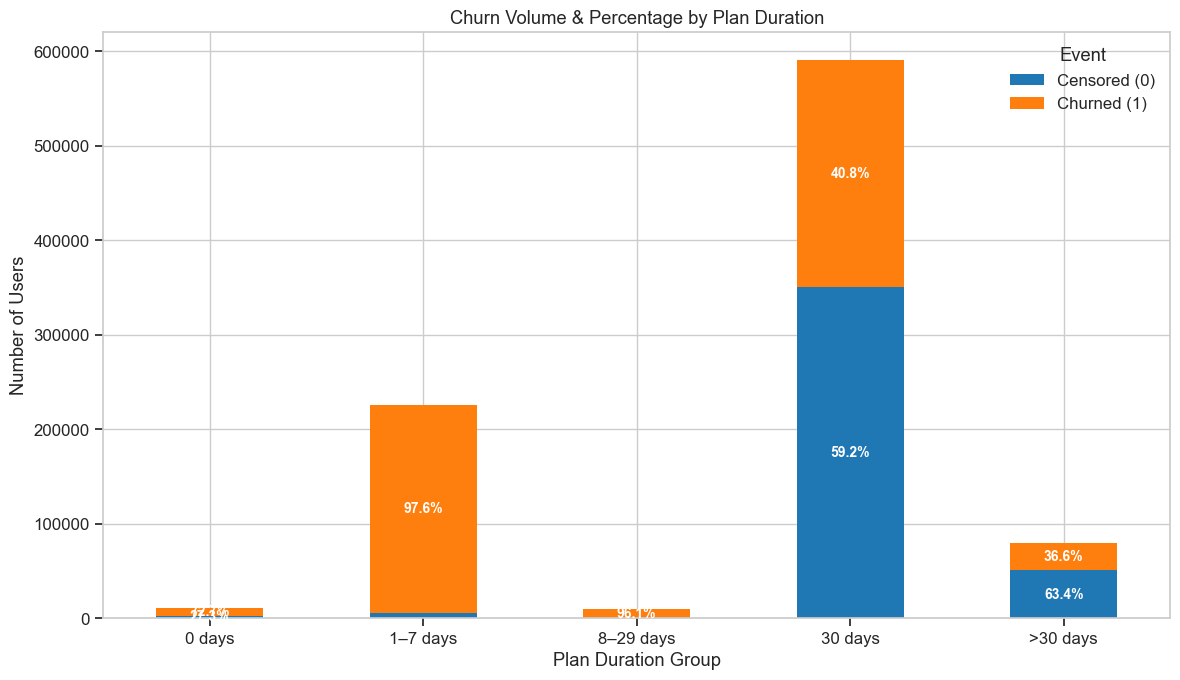

In [43]:
# Plan Duration Churn Proportions
conditions = [
    df["payment_plan_days"] == 0,
    df["payment_plan_days"].between(1, 7),
    df["payment_plan_days"].between(8, 29),
    df["payment_plan_days"] == 30,
    df["payment_plan_days"] > 30
]
labels = ["0 days", "1–7 days", "8–29 days", "30 days", ">30 days"]
df["plan_group"] = np.select(conditions, labels, default="Other")

cross_tab_plan = pd.crosstab(df['plan_group'], df['event']).reindex(labels)
cross_tab_plan_pct = cross_tab_plan.div(cross_tab_plan.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 7))
cross_tab_plan.plot(kind='bar', stacked=True, ax=ax, color=['#1f77b4', '#ff7f0e'])

for n, x in enumerate([*cross_tab_plan.index.values]):
    for (proportion, count, y_loc) in zip(cross_tab_plan_pct.loc[x], cross_tab_plan.loc[x], cross_tab_plan.loc[x].cumsum()):
        if proportion > 5:
            plt.text(x=n, y=(y_loc - count / 2), 
                     s=f'{proportion:.1f}%', 
                     color="white", fontsize=10, fontweight="bold", ha="center", va="center")

plt.title('Churn Volume & Percentage by Plan Duration')
plt.xlabel('Plan Duration Group')
plt.ylabel('Number of Users')
plt.legend(['Censored (0)', 'Churned (1)'], title='Event')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

1. **1-7 days:** Plans lasting 1 to 7 days process a significant volume of users (over 200,000) but experience a high 97.6% churn rate. This suggests these short-term options, likely 7-day trials, fail almost entirely at converting or retaining users long-term.
2. **30  days:** The monthly is the most popular duration by a wide margin, accommodating nearly 600,000 users. It is stable, retaining 59.2% of its base and losing 40.8% to churn.
3. **Over 30 days:** Users on plans extending beyond 30 days exhibit the best retention metrics across all duration groups, with a 63.4% survival rate and only 36.6% churn. However, this segment currently captures a relatively small total volume of users compared to the 30-day and 1-7 day plans.
4. **Potential Anomalies:** The "0 days" and "8-29 days" groups have negligible user volumes and suffer from extreme churn rates, including 96.1% for the 8-29 day cohort. These categories likely represent immediately canceled trials, immediate refunds or anomalies.

## Bivariate Relationships
Finally, we explore overlaps between our core transactions features.

### Plan Duration by Auto-Renew

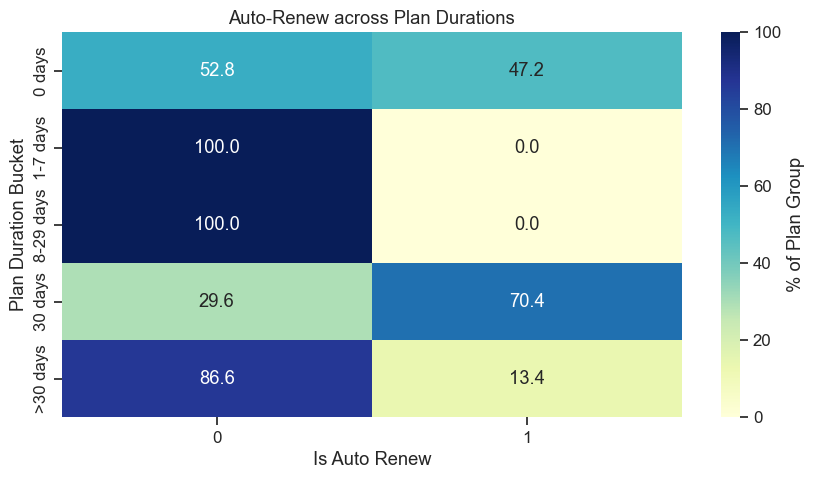

In [44]:
# Bin plan days
conditions = [
    df["payment_plan_days"] == 0,
    df["payment_plan_days"].between(1, 7),
    df["payment_plan_days"].between(8, 29),
    df["payment_plan_days"] == 30,
    df["payment_plan_days"] > 30
]
labels = ["0 days", "1-7 days", "8-29 days", "30 days", ">30 days"]
df["plan_group"] = np.select(conditions, labels, default="Other")

# Auto-Renew by Plan Group
plt.figure(figsize=(10, 5))
crosstab_auto = pd.crosstab(df['plan_group'], df['is_auto_renew'], normalize='index') * 100
crosstab_auto = crosstab_auto.loc[labels] # order correctly
sns.heatmap(crosstab_auto, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': '% of Plan Group'})
plt.title("Auto-Renew across Plan Durations")
plt.ylabel("Plan Duration Bucket")
plt.xlabel("Is Auto Renew")
plt.show()

1. **Short-Term Churn:** For both the "1-7 days" and "8-29 days" plan duration buckets, exactly 100.0% of users have auto-renew disabled. This correlates with the previously observed churn rates for these groups, particularly the 97.6% churn in the 1-7 day cohort. Because these short-term trials entirely lack auto-renewal, near-total drop-off is a certainty rather than just a behavioural trend.   
2. **30-Day Plan Stability is Auto-Renew Dependent:** The "30 days" duration is the only plan category where the majority of users (70.4%) are opted into auto-renewal. Knowing that the 30-day cohort represents the highest-volume of users and maintains a strong 59.2% survival rate, it is clear that this stability is heavily informed by the auto-renew feature. This also aligns with the finding that auto-renewing users across the platform survive at a much higher 68.7% baseline rate.
3. **Long-Term Surprise:** 86.6% of users on plans longer than 30 days operate without auto-renewal enabled. Interestingly, among plan durations, this group also demonstrated the highest overall survival rate at 63.4%. This completely goes against the overall trend where manual renewal drives massive 76.8% overall churn. It suggests that users who commit to extended durations (e.g., 195 or 410 days) have inherently high intent and upfront commitment, which dissolves the issue of manual renewal contributing strongly to churn

### Payment Methodd by Plan Group

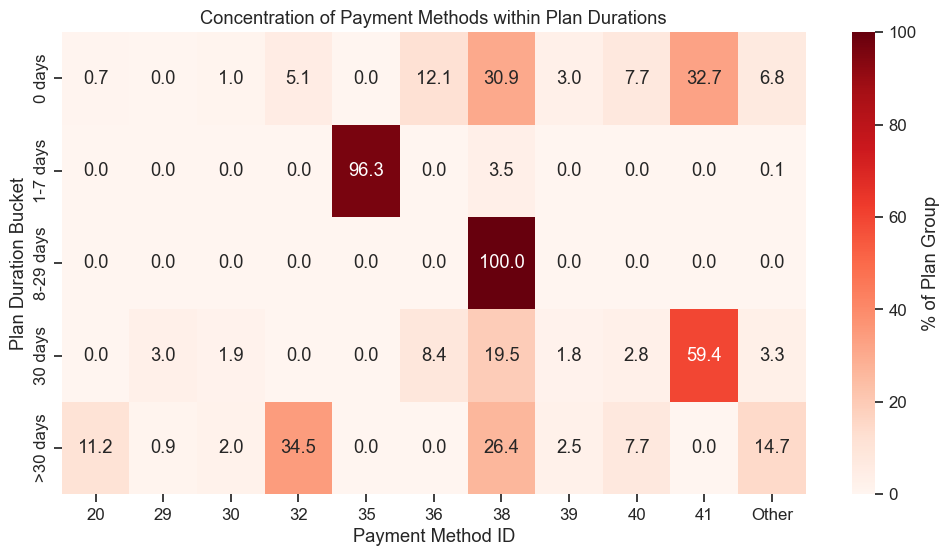

In [45]:
# Payment Method by Plan Group
top_methods = df["payment_method_id"].value_counts().nlargest(10).index
df["payment_method_grouped"] = df["payment_method_id"].apply(lambda x: str(x) if x in top_methods else "Other")

plt.figure(figsize=(12, 6))
crosstab_pm = pd.crosstab(df['plan_group'], df['payment_method_grouped'], normalize='index') * 100
crosstab_pm = crosstab_pm.loc[labels]
sns.heatmap(crosstab_pm, annot=True, fmt=".1f", cmap="Reds", cbar_kws={'label': '% of Plan Group'})
plt.title("Concentration of Payment Methods within Plan Durations")
plt.ylabel("Plan Duration Bucket")
plt.xlabel("Payment Method ID")
plt.show()

1. **The Problem with Method 35:** Payment Method 35 accounts for 96.3% of all transactions within the "1-7 days" plan bucket. We previously noted that Method 35 had a  97.8% churn rate and that the "1-7 days" plans suffered a 97.6% churn rate, with exactly 0% of those users having auto-renew enabled. This suggests that Method 35 isn't necessarily a broken payment gateway; rather, it is the dedicated channel for short-term trials that structurally guarantee immediate churn due to the lack of auto-renewal.   
2. **Method 41 Drives Business:** The stable 30-day plan relies heavily on Payment Method 41, which processes 59.4% of the users in this duration bucket. It explains why Method 41 processes the highest volume of users overall and maintains a strong 70.8% survival rate. The stability of recurring transactions is almost entirely anchored to the success of this specific payment channel and its integration with 30-day auto-renewing subscriptions.
3. **Method 32 Drives Long-Term Users:** For subscription plans extending beyond 30 days, Payment Method 32 emerges as the dominant channel, capturing 34.5% of that specific cohort. Earlier we saw that Method 32 had the best overall retention of any payment method (74.8% survival), and that users on ">30 days" plans survive at high rates despite heavily opting out of auto-renewal. Method 38 is a close second, driving 26.4% of that plan group. 
4. **The Method 38:** Payment Method 38 is uniquely scattered across the platform. It entirely monopolizes (100.0%) the highly volatile, high-churn "8-29 days" anomaly group, while also capturing a significant 19.5% of the standard 30-day plans and 26.4% of the long-term plans. Because it is heavily tied to the irregular 8-29 day plans and serves as the secondary channel for 30-day plans, its overall churn rate remains disproportionately high at 67.9% compared to Method 41. 

### Auto-Renew by Payment Method

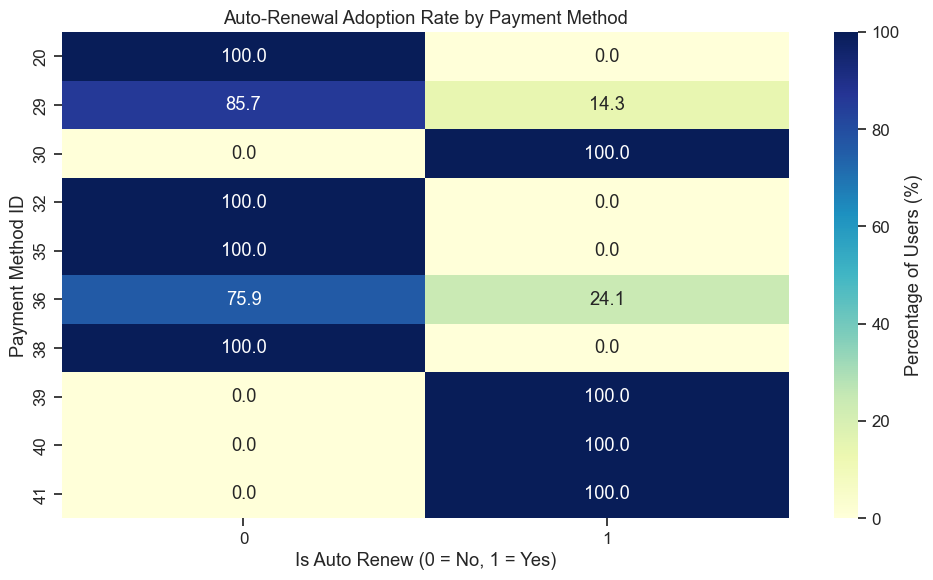

In [46]:
# Cross-tabulate Payment Method vs Auto-Renew
top_10_methods = df['payment_method_id'].value_counts().nlargest(10).index
df_top10_pay = df[df['payment_method_id'].isin(top_10_methods)]

cross_tab_pay_ar = pd.crosstab(df_top10_pay['payment_method_id'], df_top10_pay['is_auto_renew'], normalize='index') * 100

plt.figure(figsize=(10, 6))
sns.heatmap(cross_tab_pay_ar, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Percentage of Users (%)'})
plt.title('Auto-Renewal Adoption Rate by Payment Method')
plt.xlabel('Is Auto Renew (0 = No, 1 = Yes)')
plt.ylabel('Payment Method ID')
plt.tight_layout()
plt.show()

1. **Method 41 Auto-Renew Driver:** Payment Method 41 operates with exactly 100.0% of its transactions using auto-renewal. This explains why it serves as the driver for the  stable 30-day plan and maintains a dominant 70.8% retention rate, as every user acquired through this channel is mechanically opted into recurring billing.
2. **The Failure of Methods 35 and 38:** Payment Methods 35 and 38 have auto-renewal disabled for 100.0% of their users. This directly causes the catastrophic churn rates previously observed (97.8% for Method 35 and 67.9% for Method 38) proving that these channels are structurally incapable of recurring billing and function as single-payment gateways for short-term or irregular passes.
3. **Method 32 High-Intent Confirmation: Payment Method 32 completely lacks auto-renewal, showing a 100.0% manual renewal rate. This confirms that its previously noted best survival rate of 74.8% is completely driven by highly committed users making deliberate, one-off payments for long-term subscriptions exceeding 30 days.
4. **Binary Infrastructure:** The payment infrastructure is almost entirely binary regarding subscription mechanics, with methods 20, 32, 35, and 38 enforcing manual renewal, while gateways 30, 39, 40, and 41 enforce auto-renewal, leaving only Methods 29 and 36 to have a mix of both user preferences.